In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
import yaml
from pathlib import Path

from utils import (
    Config, load_checkpoint,  set_seed, visualize_training
)
from models import get_model
from optimizers import get_optimizer
from schedulers import get_scheduler
from dataset import get_dataloader
from losses import get_loss

In [2]:
CONFIG_PATH = Path("configs/conv_attn_mae_test.yaml")
CHECKPOINT_PATH = Path("checkpoints/conv_attn_mae_test_1_e20_checkpoint.pt")

In [3]:
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Config path not found: {CONFIG_PATH}")

if CHECKPOINT_PATH and not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(f"Checkpoint path not found: {CHECKPOINT_PATH}") 

# config
with open(CONFIG_PATH, "r") as f:
    config_dict = yaml.safe_load(f)
config = Config.from_dict(config_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(config.seed)

# data
loader = get_dataloader(config, split="valid")

# model / optimizer / scheduler / loss
model = get_model(
    config,
    enc_in_size=loader.dataset.enc_dim,
    dec_in_size=loader.dataset.dec_dim,
    horizon=loader.dataset.horizon,
).to(device)
optimizer = get_optimizer(config, model.parameters())
scheduler = get_scheduler(config, optimizer)
criterion = get_loss(config)

# load checkpoint
curr_epoch = 0
train_losses = []
val_losses = []

model, state_dict = load_checkpoint(
    path=CHECKPOINT_PATH, 
    model=model,
    map_location=device,
)
optimizer.load_state_dict(state_dict["optim"])

curr_epoch = state_dict["epoch"] + 1
train_losses = state_dict["train_loss"]
val_losses = state_dict["val_loss"]
print(f"Resumed '{CHECKPOINT_PATH}' at epoch {curr_epoch}.")

[valid] Dataloader initialized with: num_workers=4, batch_size=256.
Model: LSTM_ConvAttn
Optimizer: AdamW
LR Scheduler: CosineAnnealingLR
Loss function: MAE
Resumed 'checkpoints\conv_attn_mae_test_1_e20_checkpoint.pt' at epoch 20.


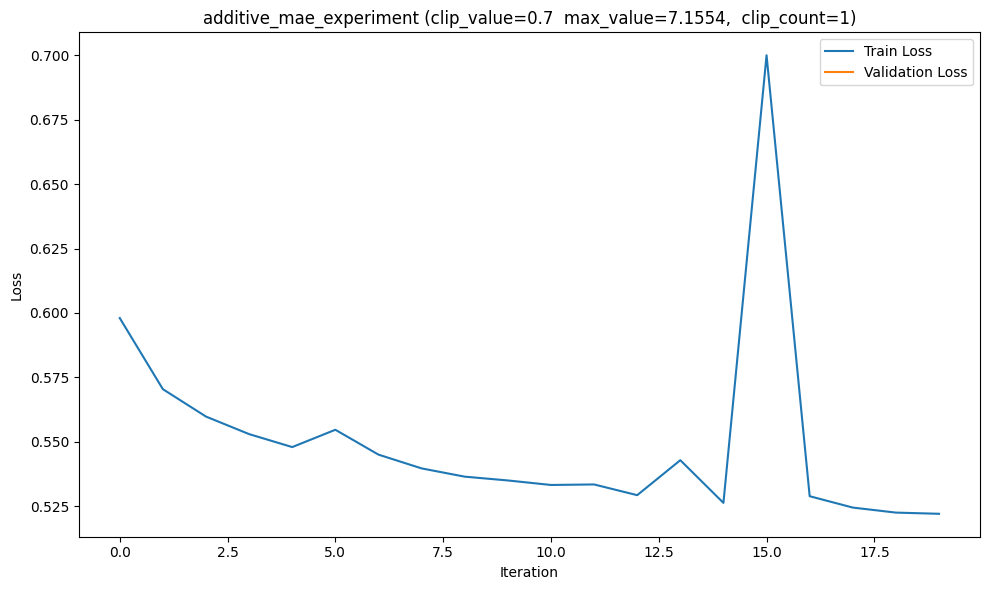

In [4]:
CLIP_MAX_VAL = 0.7
MAX_VAL = max(train_losses)
CLIP_COUNT = sum([1 for val in train_losses if val > CLIP_MAX_VAL])
# there are loss explosions in train_losses sometimes, so i gonna clip it for better visualization
train_clipped_losses = torch.tensor(train_losses, dtype=torch.float32).clamp(max=CLIP_MAX_VAL).tolist()
visualize_training(train_clipped_losses, val_losses, title=f"additive_mae_experiment (clip_value={CLIP_MAX_VAL}  max_value={MAX_VAL:.4f},  clip_count={CLIP_COUNT})")

In [5]:
from losses.smape_loss import SMAPELoss
from losses.mae_loss import MAELoss

smape_loss = SMAPELoss()
mae_loss = MAELoss()


def evaluate(model: nn.Module, loader: DataLoader, device: str = "cpu") -> tuple[float, float,
                                                                                 torch.Tensor,
                                                                                 torch.Tensor]:
    """Run inference, return (avg_mae, avg_smape, all_preds, all_targets) in original space."""
    model.eval()
    all_preds, all_targets = [], []
    total_mae = total_smape = 0

    with torch.no_grad():
        for X in tqdm(loader, desc="Eval", leave=False):
            enc_in = X["enc_input"].to(device)
            dec_in = X["dec_input"].to(device)
            target = X["target"].to(device)
            mask = X["target_mask"].to(device)
            mean = X["series_mean"].to(device)[:, None]
            std = X["series_std"].to(device)[:, None]

            pred = model(enc_in, dec_in)

            # denormalize
            pred_orig  = pred * std + mean
            target_orig = target * std + mean

            # back to pageviews space
            pred_pv = torch.expm1(pred_orig.clamp(min=0))
            target_pv = torch.expm1(target_orig.clamp(min=0))

            # MAE
            mae = mae_loss(pred_pv, target_pv, mask)
            total_mae += mae.sum().item()
            # SMAPE
            smape = smape_loss(pred_pv, target_pv, mask)
            total_smape += smape.sum().item()

            all_preds.append(pred_pv.cpu())
            all_targets.append(target_pv.cpu())

    avg_mae = total_mae / len(loader)
    avg_smape = total_smape / len(loader)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    return avg_mae, avg_smape, all_preds, all_targets

In [6]:
def plot_samples(all_preds: torch.Tensor, 
                 all_targets: torch.Tensor, 
                 n_series: int = 6, 
                 seed: int = 0) -> None:
    """Plot n random series: true vs predicted."""
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(all_preds), size=n_series, replace=False)

    cols = 3
    rows = (n_series + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 3))
    axes = axes.flatten()

    for i, idx in enumerate(idxs):
        ax = axes[i]
        pred = all_preds[idx].numpy()
        target = all_targets[idx].numpy()
        ax.plot(target, label="true", color="steelblue")
        ax.plot(pred, label="pred", color="tomato", linestyle="--")
        ax.set_title(f"series #{idx}")
        ax.legend(fontsize=8)
        ax.set_xlabel("day")
        ax.set_ylabel("views")

    for ax in axes[n_series:]:
        ax.set_visible(False)

    plt.suptitle("True vs Predicted", y=1.02)
    plt.tight_layout()
    plt.show()

MAE (pageviews): 112.96
SMAPE (%): 0.2707


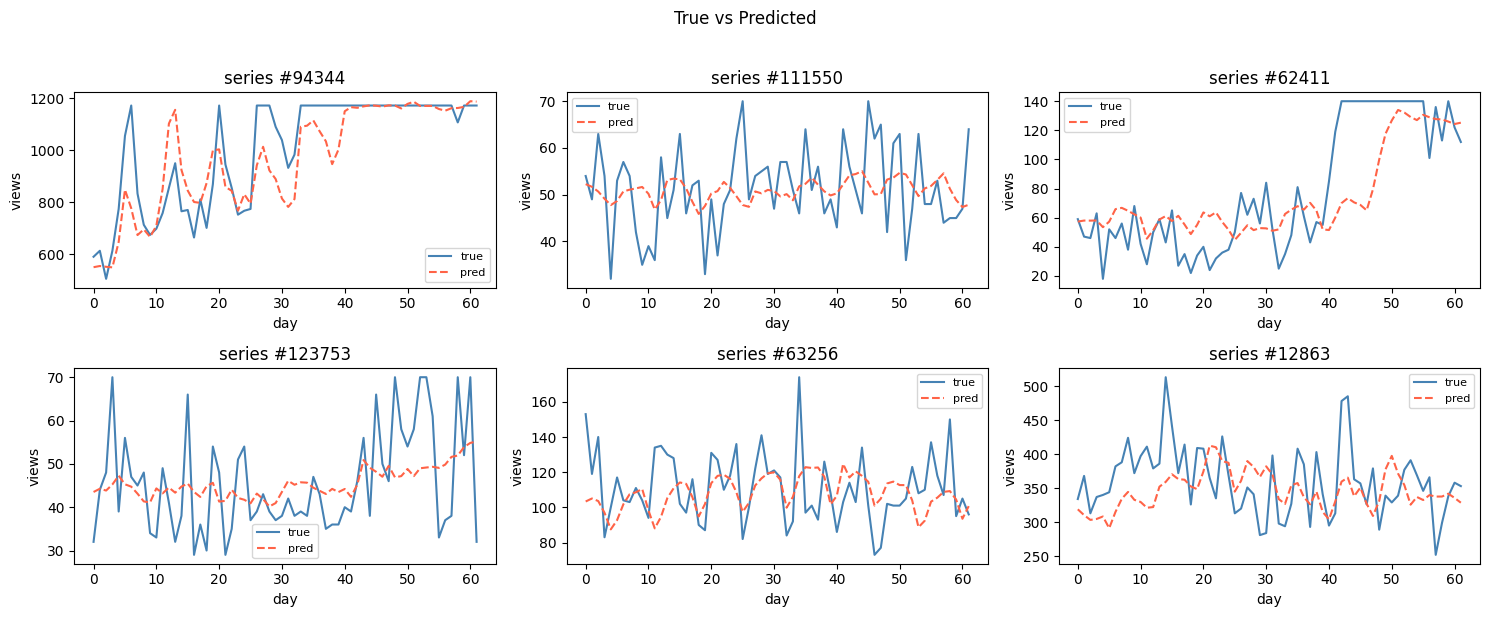

In [7]:
mae, smape, all_preds, all_targets = evaluate(model, loader, device)
print(f"MAE (pageviews): {mae:.2f}")
print(f"SMAPE (%): {smape:.4f}")

plot_samples(all_preds, all_targets, n_series=6, seed=42)